# Spam Detection 


## 1. Imports & Load Data

In [1]:
import pandas as pd
import numpy as np
import re
import math
from collections import defaultdict, Counter

df = pd.read_csv('spam.csv', encoding='latin-1')
df = df[['v1', 'v2']]
df.columns = ['label', 'text']
df['label'] = df['label'].map({'ham': 0, 'spam': 1})
print(df.shape)
df.head()

(5572, 2)


,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


## 2. Pre-processing

In [2]:
# ---- stopwords (no nltk needed) ----
STOPWORDS = set([
    'i','me','my','myself','we','our','ours','ourselves','you','your','yours',
    'yourself','he','him','his','himself','she','her','hers','herself','it',
    'its','itself','they','them','their','theirs','themselves','what','which',
    'who','whom','this','that','these','those','am','is','are','was','were',
    'be','been','being','have','has','had','having','do','does','did','doing',
    'a','an','the','and','but','if','or','because','as','until','while','of',
    'at','by','for','with','about','against','between','into','through',
    'during','before','after','above','below','to','from','up','down','in',
    'out','on','off','over','under','again','further','then','once','here',
    'there','when','where','why','how','all','both','each','few','more',
    'most','other','some','such','no','nor','not','only','own','same','so',
    'than','too','very','s','t','can','will','just','don','should','now',
    'd','ll','m','o','re','ve','y','ain','aren','couldn','didn','doesn',
    'hadn','hasn','haven','isn','ma','mightn','mustn','needn','shan',
    'shouldn','wasn','weren','won','wouldn'
])

def clean_text(text):
    text = text.lower()                          # lowercase
    text = re.sub(r'[^a-z0-9 ]', ' ', text)     # keep letters & numbers only
    words = text.split()
    words = [w for w in words if w not in STOPWORDS and len(w) > 1]
    return ' '.join(words)

df['cleaned'] = df['text'].apply(clean_text)
print("Sample cleaned:")
print(df[['text','cleaned']].head(3).to_string())

Sample cleaned:
                                                                                                                                                          text                                                                                                                             cleaned
0                                              Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...                                                      go jurong point crazy available bugis great world la buffet cine got amore wat
1                                                                                                                                Ok lar... Joking wif u oni...                                                                                                               ok lar joking wif oni
2  Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry questi

## 3. TF-IDF from Scratch

In [3]:
class TFIDFVectorizer:
    """
    TF-IDF vectorizer built completely from scratch.
    TF(t,d)  = count(t in d) / total_words(d)
    IDF(t)   = log( (1 + N) / (1 + df(t)) ) + 1
    TF-IDF   = TF * IDF  (then L2-normalized per document)
    """

    def fit(self, docs):
        N = len(docs)
        # count in how many docs each word appears
        doc_freq = defaultdict(int)
        for doc in docs:
            for word in set(doc.split()):
                doc_freq[word] += 1

        # build vocabulary (sorted for consistency)
        self.vocab = sorted(doc_freq.keys())
        self.word2idx = {w: i for i, w in enumerate(self.vocab)}
        self.V = len(self.vocab)

        # pre-compute IDF for every word
        self.idf = np.array([
            math.log((1 + N) / (1 + doc_freq[w])) + 1
            for w in self.vocab
        ])
        return self

    def transform(self, docs):
        rows = []
        for doc in docs:
            words = doc.split()
            total = len(words) if words else 1
            counts = Counter(words)

            vec = np.zeros(self.V)
            for word, cnt in counts.items():
                if word in self.word2idx:
                    idx = self.word2idx[word]
                    tf = cnt / total
                    vec[idx] = tf * self.idf[idx]

            # L2 normalization
            norm = np.linalg.norm(vec)
            if norm > 0:
                vec = vec / norm
            rows.append(vec)
        return np.array(rows)

    def fit_transform(self, docs):
        return self.fit(docs).transform(docs)

print("TFIDFVectorizer defined ✓")

TFIDFVectorizer defined ✓


## 4. Train / Test Split from Scratch

In [4]:
def train_test_split_scratch(X, y, test_size=0.2, seed=42):
    np.random.seed(seed)
    indices = np.random.permutation(len(X))
    split = int(len(X) * (1 - test_size))
    train_idx, test_idx = indices[:split], indices[split:]
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

# Vectorize
tfidf = TFIDFVectorizer()
X_all = tfidf.fit_transform(df['cleaned'].tolist())
y_all = df['label'].values

X_train, X_test, y_train, y_test = train_test_split_scratch(X_all, y_all)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (4457, 8487), Test: (1115, 8487)


## 5. Helper: Accuracy

In [5]:
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

results = {}  # will store {model_name: accuracy}

---
# Algorithm 1 — Naive Bayes 


In [6]:
class NaiveBayes:

    def fit(self, X, y):
        self.classes = np.unique(y)
        self.priors = {}   # P(class)
        self.means  = {}   # mean per feature per class
        self.vars   = {}   # variance per feature per class

        for c in self.classes:
            Xc = X[y == c]
            self.priors[c] = len(Xc) / len(X)
            self.means[c]  = Xc.mean(axis=0)
            # add small epsilon to avoid division by zero
            self.vars[c]   = Xc.var(axis=0) + 1e-9
        return self

    def _log_likelihood(self, x, c):
        """log P(x | class=c) under Gaussian assumption  ​]"""
        mu  = self.means[c]
        var = self.vars[c]
        # log of Gaussian PDF, summed over features
        log_p = -0.5 * np.sum(np.log(2 * np.pi * var) + ((x - mu) ** 2) / var)
        return log_p

    def predict(self, X):
        preds = []
        for x in X:
            scores = {
                c: np.log(self.priors[c]) + self._log_likelihood(x, c)
                for c in self.classes
            }
            preds.append(max(scores, key=scores.get))
        return np.array(preds)


nb = NaiveBayes().fit(X_train, y_train)
pred_nb = nb.predict(X_test)
acc_nb = accuracy(y_test, pred_nb)
results['Naive Bayes'] = acc_nb
print(f"Naive Bayes Accuracy: {acc_nb*100:.2f}%")

Naive Bayes Accuracy: 88.70%


---
# Algorithm 2 — Logistic Regression 


In [7]:
class LogisticRegression:
   

    def __init__(self, lr=0.1, n_iters=200):
        self.lr = lr
        self.n_iters = n_iters

    def _sigmoid(self, z):
        # clip to prevent overflow in exp
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias    = 0.0

        for _ in range(self.n_iters):
            # Forward pass
            z    = X @ self.weights + self.bias
            y_hat = self._sigmoid(z)              # predictions (0–1)

            # Gradients (from cross-entropy loss)
            error = y_hat - y
            dw = (X.T @ error) / n_samples
            db = error.mean()

            # Gradient Descent update
            self.weights -= self.lr * dw
            self.bias    -= self.lr * db
        return self

    def predict(self, X):
        probs = self._sigmoid(X @ self.weights + self.bias)
        return (probs >= 0.5).astype(int)

    def predict_proba(self, X):
        return self._sigmoid(X @ self.weights + self.bias)


lr_model = LogisticRegression(lr=0.1, n_iters=200).fit(X_train, y_train)
pred_lr  = lr_model.predict(X_test)
acc_lr   = accuracy(y_test, pred_lr)
results['Logistic Regression'] = acc_lr
print(f"Logistic Regression Accuracy: {acc_lr*100:.2f}%")

Logistic Regression Accuracy: 85.92%


---
# Algorithm 3 — K-Nearest Neighbors 


In [8]:
class KNN:
   

    def __init__(self, k=5):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
        return self

    def _euclidean(self, a, b):
        return np.sqrt(np.sum((a - b) ** 2))

    def predict(self, X):
        preds = []
        for x in X:
            # compute distance to every training sample
            distances = np.array([self._euclidean(x, xt) for xt in self.X_train])
            # pick k nearest indices
            k_idx = np.argsort(distances)[:self.k]
            # majority vote
            k_labels = self.y_train[k_idx]
            vote = Counter(k_labels).most_common(1)[0][0]
            preds.append(vote)
        return np.array(preds)


knn = KNN(k=5).fit(X_train, y_train)
pred_knn = knn.predict(X_test)
acc_knn  = accuracy(y_test, pred_knn)
results['KNN'] = acc_knn
print(f"KNN Accuracy: {acc_knn*100:.2f}%")

KNN Accuracy: 89.96%


---
# Algorithm 4 — Decision Tree 

In [9]:
class DecisionTree:
   

    def __init__(self, max_depth=10, min_samples=5, max_features=200):
        self.max_depth   = max_depth
        self.min_samples = min_samples
        self.max_features = max_features  # only check a subset of features (speed)
        self.tree = None

    def _gini(self, y):
        if len(y) == 0:
            return 0
        classes, counts = np.unique(y, return_counts=True)
        probs = counts / len(y)
        return 1 - np.sum(probs ** 2)

    def _best_split(self, X, y):
        best_gain = -1
        best_feat = best_thresh = None
        parent_gini = self._gini(y)
        n = len(y)

        # randomly pick a subset of features to check (faster)
        feat_indices = np.random.choice(X.shape[1],
                                         min(self.max_features, X.shape[1]),
                                         replace=False)

        for feat in feat_indices:
            col = X[:, feat]
            thresholds = np.unique(col)
            if len(thresholds) > 20:
                thresholds = np.percentile(col, np.linspace(10, 90, 10))

            for thresh in thresholds:
                left_mask  = col <= thresh
                right_mask = ~left_mask
                if left_mask.sum() < self.min_samples or right_mask.sum() < self.min_samples:
                    continue

                y_l, y_r = y[left_mask], y[right_mask]
                child_gini = (len(y_l)/n)*self._gini(y_l) + (len(y_r)/n)*self._gini(y_r)
                gain = parent_gini - child_gini

                if gain > best_gain:
                    best_gain, best_feat, best_thresh = gain, feat, thresh

        return best_feat, best_thresh

    def _build(self, X, y, depth):
        # stopping conditions
        if depth >= self.max_depth or len(y) < self.min_samples or len(np.unique(y)) == 1:
            return {'leaf': True, 'class': Counter(y).most_common(1)[0][0]}

        feat, thresh = self._best_split(X, y)
        if feat is None:
            return {'leaf': True, 'class': Counter(y).most_common(1)[0][0]}

        left_mask = X[:, feat] <= thresh
        return {
            'leaf':   False,
            'feat':   feat,
            'thresh': thresh,
            'left':   self._build(X[left_mask],  y[left_mask],  depth+1),
            'right':  self._build(X[~left_mask], y[~left_mask], depth+1)
        }

    def fit(self, X, y):
        np.random.seed(42)
        self.tree = self._build(X, y, 0)
        return self

    def _traverse(self, node, x):
        if node['leaf']:
            return node['class']
        if x[node['feat']] <= node['thresh']:
            return self._traverse(node['left'],  x)
        else:
            return self._traverse(node['right'], x)

    def predict(self, X):
        return np.array([self._traverse(self.tree, x) for x in X])


dt = DecisionTree(max_depth=10, min_samples=5, max_features=200).fit(X_train, y_train)
pred_dt = dt.predict(X_test)
acc_dt  = accuracy(y_test, pred_dt)
results['Decision Tree'] = acc_dt
print(f"Decision Tree Accuracy: {acc_dt*100:.2f}%")

Decision Tree Accuracy: 90.49%


---
# Algorithm 5 — Random Forest 

In [10]:
class RandomForest:
   

    def __init__(self, n_trees=10, max_depth=8, min_samples=5, max_features=150):
        self.n_trees     = n_trees
        self.max_depth   = max_depth
        self.min_samples = min_samples
        self.max_features = max_features
        self.trees = []

    def _bootstrap(self, X, y):
        """Sample with replacement (bootstrap)"""
        idx = np.random.choice(len(X), size=len(X), replace=True)
        return X[idx], y[idx]

    def fit(self, X, y):
        np.random.seed(42)
        self.trees = []
        for i in range(self.n_trees):
            X_boot, y_boot = self._bootstrap(X, y)
            tree = DecisionTree(
                max_depth=self.max_depth,
                min_samples=self.min_samples,
                max_features=self.max_features
            )
            tree.fit(X_boot, y_boot)
            self.trees.append(tree)
            print(f"  Tree {i+1}/{self.n_trees} trained", end='\r')
        print("\nAll trees done!")
        return self

    def predict(self, X):
        # collect predictions from all trees → shape (n_trees, n_samples)
        all_preds = np.array([tree.predict(X) for tree in self.trees])
        # majority vote for each sample
        final = []
        for col in all_preds.T:
            vote = Counter(col).most_common(1)[0][0]
            final.append(vote)
        return np.array(final)


rf = RandomForest(n_trees=10, max_depth=8, max_features=150).fit(X_train, y_train)
pred_rf = rf.predict(X_test)
acc_rf  = accuracy(y_test, pred_rf)
results['Random Forest'] = acc_rf
print(f"Random Forest Accuracy: {acc_rf*100:.2f}%")

  Tree 10/10 trained
All trees done!
Random Forest Accuracy: 88.97%


---
## 6. Results Summary

  Model Comparison (Accuracy)
Decision Tree        90.49%  ████████████████████████████████████
KNN                  89.96%  ███████████████████████████████████
Random Forest        88.97%  ███████████████████████████████████
Naive Bayes          88.70%  ███████████████████████████████████
Logistic Regression  85.92%  ██████████████████████████████████


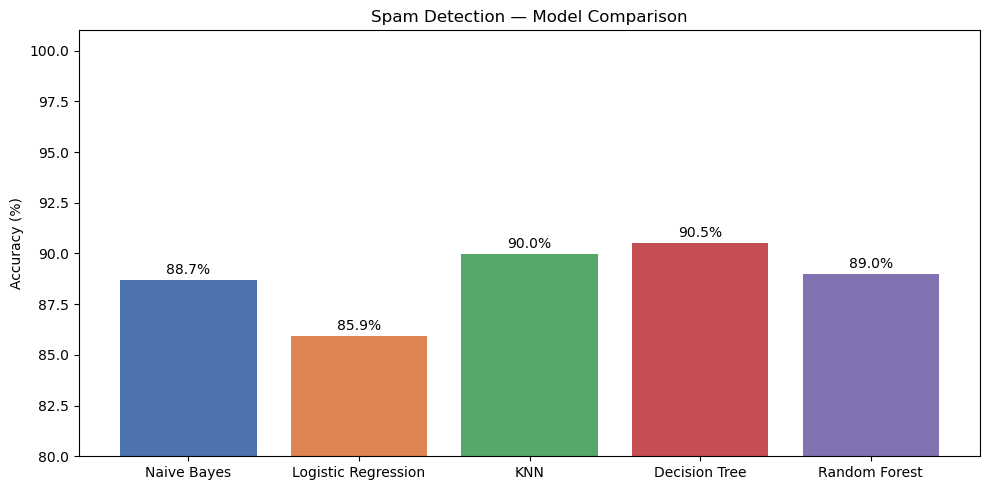

In [11]:
import matplotlib.pyplot as plt

print("=" * 40)
print("  Model Comparison (Accuracy)")
print("=" * 40)
for name, acc in sorted(results.items(), key=lambda x: -x[1]):
    bar = '█' * int(acc * 40)
    print(f"{name:<20} {acc*100:5.2f}%  {bar}")

# Bar chart
plt.figure(figsize=(10, 5))
plt.bar(results.keys(), [v*100 for v in results.values()], color=['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2'])
plt.ylim(80, 101)
plt.ylabel('Accuracy (%)')
plt.title('Spam Detection — Model Comparison')
for i, (name, acc) in enumerate(results.items()):
    plt.text(i, acc*100 + 0.3, f'{acc*100:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

---
## 7. Prediction Function + GUI 

In [12]:
def predict_message(text):
    """
    Takes raw text, cleans it, vectorizes it, runs all 5 models.
    Returns dict {model_name: 'Spam'/'Not Spam'}
    """
    cleaned = clean_text(text)
    vec = tfidf.transform([cleaned])   # shape (1, V)

    return {
        'Naive Bayes':        'Spam' if nb.predict(vec)[0]      == 1 else 'Not Spam',
        'Logistic Regression':'Spam' if lr_model.predict(vec)[0] == 1 else 'Not Spam',
        'KNN':                'Spam' if knn.predict(vec)[0]      == 1 else 'Not Spam',
        'Decision Tree':      'Spam' if dt.predict(vec)[0]       == 1 else 'Not Spam',
        'Random Forest':      'Spam' if rf.predict(vec)[0]       == 1 else 'Not Spam',
    }

# Quick test
test_msg = "Congratulations! You won a FREE iPhone. Click now to claim your prize!"
print("Message:", test_msg)
print("Results:", predict_message(test_msg))

Message: Congratulations! You won a FREE iPhone. Click now to claim your prize!
Results: {'Naive Bayes': 'Not Spam', 'Logistic Regression': 'Not Spam', 'KNN': 'Not Spam', 'Decision Tree': 'Spam', 'Random Forest': 'Not Spam'}


In [ ]:
import tkinter as tk
from tkinter import font as tkfont

def run_gui():
    root = tk.Tk()
    root.title("Spam Detection App")
    root.geometry("700x520")
    root.configure(bg='#f0f4f8')

    title_font  = tkfont.Font(family='Helvetica', size=16, weight='bold')
    label_font  = tkfont.Font(family='Helvetica', size=11)
    result_font = tkfont.Font(family='Helvetica', size=11, weight='bold')

    # Title
    tk.Label(root, text="📧 Spam Detection", font=title_font,
             bg='#f0f4f8', fg='#2d3436').pack(pady=(18,4))

    # Input
    tk.Label(root, text="Enter message:", font=label_font,
             bg='#f0f4f8', anchor='w').pack(fill='x', padx=30)
    input_box = tk.Text(root, height=4, width=70, font=label_font,
                        relief='solid', bd=1, padx=6, pady=6)
    input_box.pack(padx=30, pady=4)

    # Result entries
    model_names = ['Naive Bayes', 'Logistic Regression', 'KNN',
                   'Decision Tree', 'Random Forest']
    result_vars = {}
    frame = tk.Frame(root, bg='#f0f4f8')
    frame.pack(padx=30, pady=8, fill='x')

    for i, name in enumerate(model_names):
        tk.Label(frame, text=f"{name}:", font=label_font,
                 bg='#f0f4f8', width=22, anchor='w').grid(row=i, column=0, pady=4)
        var = tk.StringVar(value="—")
        result_vars[name] = var
        entry = tk.Entry(frame, textvariable=var, font=result_font,
                         width=20, state='readonly', relief='solid',
                         readonlybackground='#ffffff')
        entry.grid(row=i, column=1, pady=4, padx=8)

    def on_process():
        text = input_box.get('1.0', 'end').strip()
        if not text:
            return
        preds = predict_message(text)
        for name, label in preds.items():
            result_vars[name].set(label)

    tk.Button(root, text="Process", command=on_process,
              font=result_font, bg='#0984e3', fg='white',
              relief='flat', padx=20, pady=8,
              cursor='hand2').pack(pady=12)

    root.mainloop()

 
run_gui()

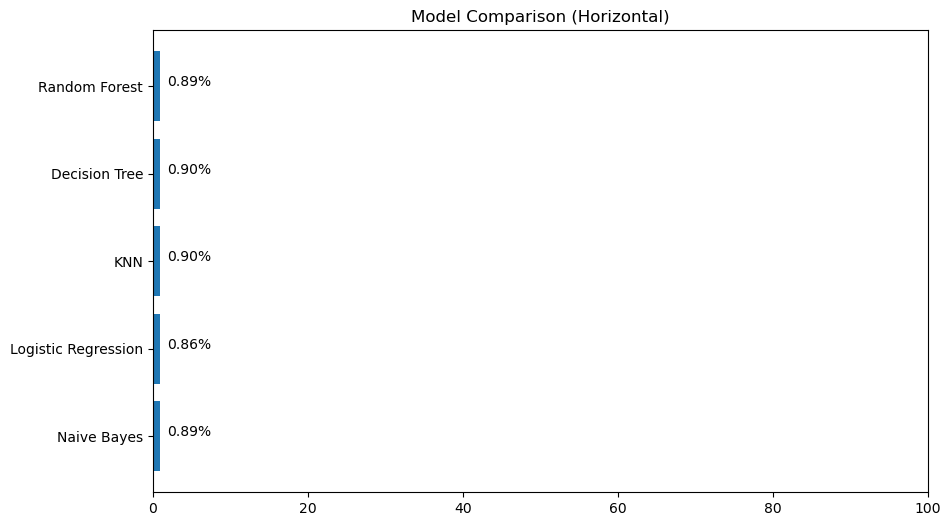

In [ ]:
plt.figure(figsize=(10,6))
plt.barh(list(results.keys()), list(results.values()))

plt.xlim(0, 100)
plt.title("Model Comparison (Horizontal)")

for i, v in enumerate(results.values()):
    plt.text(v + 1, i, f"{v:.2f}%")

plt.show()